Piecewise_Model


Running ess...
 14.512280 seconds (217.71 M allocations: 6.538 GiB, 14.11% gc time, 2.68% compilation time)
Running mh...
  1.441024 seconds (21.33 M allocations: 686.253 MiB, 8.57% gc time, 3.59% compilation time)
Log Likelihood (ess): -54.60587777240484
Log Likelihood (mh): -53.17799611499511


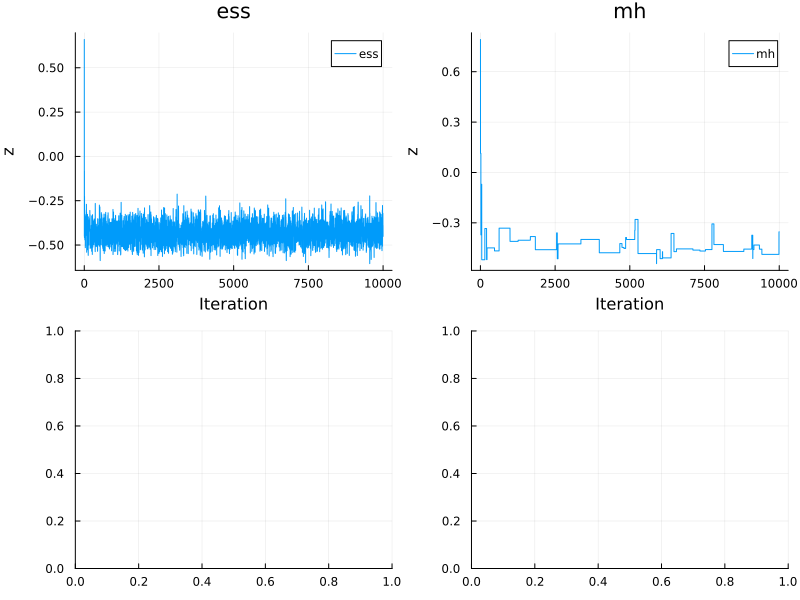

In [17]:
using Gen, Distributions, Plots, StatsPlots

# A distribution that is guaranteed to be 1 or higher.
@dist poisson_plus_one(rate) = poisson(rate) + 1;

function logmeanexp(scores)
    logsumexp(scores) - log(length(scores))
end;

# Define the piecewise_constant model
@gen function piecewise_constant(xs::Vector{Float64})
    # Generate a number of segments (at least 1)
    segment_count ~ poisson_plus_one(1)
    
    # Draw a vector on the simplex from a Dirichlet distribution
    fractions ~ Gen.dirichlet(ones(segment_count))

    # Generate values for each segment
    segments = [{(:segments, i)} ~ normal(0, 1) for i=1:segment_count]
    
    # Determine a global noise level (gamma-distributed)
    z ~ normal(0, 1)  # z is Normally distributed
    noise = quantile(Gamma(1, 1), cdf(Normal(0, 1), z))  # Transform z to noise using the gamma CDF
    
    # Generate the y points for the input x points
    xmin, xmax = extrema(xs)
    cumfracs = cumsum(fractions)
    cumfracs[end] = 1.0  # Ensure the last cumulative fraction is exactly 1.0

    inds = [findfirst(frac -> frac >= (x - xmin) / (xmax - xmin), cumfracs) for x in xs]
    segment_values = segments[inds]
    for (i, val) in enumerate(segment_values)
        {(:y, i)} ~ normal(val, noise)
    end
end

# Generalized Elliptical Slice Sampling (ESS)
function elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
    # Current parameter value(s) for the selected addresses
    current_values = [get_choices(tr)[addr] for addr in addresses]

    # Extract prior mean (m0) and variance (t2) for each selected address
    prior_means = []
    prior_vars = []
    for addr in addresses
        # Get the prior distribution for the selected address
        prior_dist = prior_dict[addr]
        # Extract mean and variance from the prior distribution
        if prior_dist isa Normal
            push!(prior_means, prior_dist.μ)
            push!(prior_vars, prior_dist.σ^2)
        else
            error("Prior distribution for $addr is not Normal. ESS requires Normal priors.")
        end
    end

    # Standard deviations for the priors
    prior_stds = sqrt.(prior_vars)

    # Center the current values so the priors are ~N(0, prior_std^2)
    current_values_offset = current_values .- prior_means

    # Sample a random "direction" from the same priors: N(0, prior_std^2)
    nu = prior_stds .* randn(length(current_values))

    # Current log probability (includes prior + likelihood)
    logp_cur = Gen.get_score(tr)

    # Slice threshold: uniformly pick a threshold below logp_cur
    logy = logp_cur + log(rand())

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        proposed_offset = current_values_offset .* cos(theta) + nu .* sin(theta)
        # Shift back by prior means
        proposed_values = prior_means .+ proposed_offset

        # Create a ChoiceMap with the proposed values
        temp_cm = Gen.choicemap()
        for (i, addr) in enumerate(addresses)
            temp_cm[addr] = proposed_values[i]
        end

        # Attempt to update the trace with the new values
        (temp_tr, _, re_score) = Gen.update(tr, args, (), temp_cm)

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end

# Function to compute log likelihood
function compute_log_likelihood(traces)
    log_likelihoods = [get_score(tr) for tr in traces]
    mean_log_likelihood = logmeanexp(log_likelihoods)
    return mean_log_likelihood
end

# Function to run inference
function run_inference(method, model, args, observations, addresses, prior_dict, num_samples)
    traces = []
    (tr, _) = generate(model, args, observations)
    for iter=1:num_samples
        if method == :ess
            tr = elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
        elseif method == :is
            (tr, _) = importance_sampling(model, args, observations)
        elseif method == :mh
            (tr, _) = mh(tr, select(addresses...))
        elseif method == :hmc
            (tr, _) = hmc(tr, select(addresses...))
        end
        push!(traces, tr)
    end
    return traces
end

# Example usage
function main()
    # Define the model arguments
    xs = collect(range(0, stop=10, length=100))  # Input x values
    args = (xs,)  # Arguments for the piecewise_constant model

    # Define the observations (constraints)
    ys = sin.(xs) .+ randn(length(xs)) * 0.1  # Simulated y values
    ys = max.(ys, 0.0)  # Ensure ys is non-negative

    observations = Gen.choicemap()
    for (i, y) in enumerate(ys)
        observations[(:y, i)] = y
    end

    # Define the addresses of variables to update
    addresses = [:z, (:segments, 1), (:segments, 2)]  # Update z and segments

    # Define the prior dictionary using addresses as keys
    prior_dict = Dict(
        :z => Normal(0, 1),  # Prior for z (transformed noise)
        (:segments, 1) => Normal(0, 1),  # Prior for segment 1
        (:segments, 2) => Normal(0, 1)   # Prior for segment 2
    )

    # Run inference for all methods
    methods = [:ess, :mh]
    results = Dict()
    for method in methods
        println("Running $method...")
        @time traces = run_inference(method, piecewise_constant, args, observations, addresses, prior_dict, 10000)
        results[method] = traces
    end

    # Compare log likelihood
    for method in methods
        mean_log_likelihood = compute_log_likelihood(results[method])
        println("Log Likelihood ($method): ", mean_log_likelihood)
    end

    # Plot traces for z
    plt = plot(layout=(2, 2), size=(800, 600))
    for (i, method) in enumerate(methods)
        z_samples = [get_choices(tr)[:z] for tr in results[method]]
        plot!(plt[i], z_samples, xlabel="Iteration", ylabel="z", label=string(method), title=string(method))
    end
    display(plt)
end

# Run the main function
main()